# Analyse causale — Groupama-FDJ 2025
## Statistiques descriptives + Premiers modèles causaux

**Objectif de ce notebook :** Comprendre les données, poser les bonnes questions, et lancer les premiers modèles causaux en sachant exactement ce qu'on fait et pourquoi.

---
**Structure :**
1. Chargement des données
2. Statistiques descriptives
3. Pourquoi le ML classique ne suffit pas ?
4. Double Machine Learning (DML) — ATE
5. Causal Forest — Hétérogénéité
6. Questions ouvertes pour Bram & Dries

## 0. Imports & Configuration

In [30]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from econml.dml import CausalForestDML
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

RIDER_DIR = '/Users/arthurdeletang/Desktop/Stage M1/Code/rider_data'
RACE_PATH = '/Users/arthurdeletang/Desktop/Stage M1/Code/race_data/race_features.csv'
ANNEE     = 2025
EQUIPE    = 'Team Visma | Lease a Bike'

# Liste des coureurs FDJ 2025 (détectée automatiquement)
def find_team_riders(equipe, annee, rider_dir):
    riders = []
    for f in os.listdir(rider_dir):
        if not f.endswith('.csv'):
            continue
        try:
            df = pd.read_csv(os.path.join(rider_dir, f), usecols=['year', 'equipe'])
            if ((df['year'] == annee) & (df['equipe'] == equipe)).any():
                riders.append(f)
        except:
            continue
    return sorted(riders)

RIDERS = find_team_riders(EQUIPE, ANNEE, RIDER_DIR)
print(f'{len(RIDERS)} coureurs FDJ 2025 detectes')

39 coureurs FDJ 2025 detectes


In [34]:
import os
import pandas as pd

RIDER_DIR = '/Users/arthurdeletang/Desktop/Stage M1/Code/rider_data'

for nom in ['vingegaard_jonas', 'van_aert_wout']:
    path = os.path.join(RIDER_DIR, f'{nom}.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'{nom} :')
        print(df[df['year'].isin([2024, 2025])]['equipe'].unique())
    else:
        print(f'{nom} : FICHIER INTROUVABLE')
        # Chercher un nom proche
        candidates = [f for f in os.listdir(RIDER_DIR) if 'aert' in f or 'vingegaard' in f]
        print(f'  Candidats : {candidates}')

vingegaard_jonas :
['Team Visma | Lease a Bike' 'Denmark']
van_aert_wout :
['Team Visma | Lease a Bike' 'Belgium']


## 1. Chargement des données

### Ce qu'on charge
- **rider_data/** : un CSV par coureur avec ses résultats course par course. La variable clé est `selected` (1 = le coureur était dans l'équipe sur cette course, 0 = il ne l'était pas) et `pts_uci_equipe` (points UCI de toute l'équipe sur cette course/étape).
- **race_features.csv** : les caractéristiques physiques de chaque course (distance, dénivelé, cols, gradient, surfaces Komoot...).

### La jointure
On joint les deux sur `(course, year, stage_num)` pour avoir, pour chaque ligne, à la fois les infos sur le coureur ET les infos sur la course.

In [31]:
def load_rider(filename, annee, equipe):
    df_rider = pd.read_csv(os.path.join(RIDER_DIR, filename))
    df_race  = pd.read_csv(RACE_PATH)
    df_rider = df_rider[(df_rider['year'] == annee) & (df_rider['equipe'] == equipe)]
    if len(df_rider) == 0:
        return None
    df_rider['stage_num'] = pd.to_numeric(df_rider['etape'],    errors='coerce')
    df_rider['year']      = pd.to_numeric(df_rider['year'],     errors='coerce').astype('Int64')
    df_race['year']       = pd.to_numeric(df_race['year'],      errors='coerce').astype('Int64')
    df_race['stage_num']  = pd.to_numeric(df_race['stage_num'], errors='coerce')
    df_rider['rider']     = filename.replace('.csv', '')
    return df_rider.merge(
        df_race.drop(columns=['stage', 'classification', 'date'], errors='ignore'),
        on=['course', 'year', 'stage_num'], how='left'
    )

# Charger tous les coureurs FDJ
dfs = [load_rider(f, ANNEE, EQUIPE) for f in RIDERS]
df_fdj = pd.concat([d for d in dfs if d is not None], ignore_index=True)

print(f'Dataset FDJ 2025 :')
print(f'  {df_fdj["rider"].nunique()} coureurs | {len(df_fdj)} lignes | {df_fdj["course"].nunique()} courses uniques')
print(f'  selected=1 : {(df_fdj["selected"]==1).sum()} | selected=0 : {(df_fdj["selected"]==0).sum()}')
print(f'  Match GPX  : {df_fdj["distance_gpx_km"].notna().sum()}/{len(df_fdj)} ({df_fdj["distance_gpx_km"].notna().mean()*100:.1f}%)')
df_fdj.head(3)

Dataset FDJ 2025 :
  39 coureurs | 9782 lignes | 80 courses uniques
  selected=1 : 1650 | selected=0 : 8132
  Match GPX  : 9433/9782 (96.4%)


,date,year,course,type,etape,equipe,classification,statut,rang,pts_uci,...,loc_last_col_cat3,loc_last_col_cat2,loc_last_col_cat1,loc_last_col_hc,gradient_last_1km,gradient_last_3km,gradient_last_5km,denivele_last_5km,gradient_first_50km,denivele_first_50km
0,2025-05-14,2025,4-jours-de-dunkerque,stage,1.00,Team Visma | Lease a Bike,2.Pro,NaN,NaN,0.00,...,0.00,0.00,0.00,0.00,-0.90,-1.40,-0.98,507.00,0.19,489.00
1,2025-05-15,2025,4-jours-de-dunkerque,stage,2.00,Team Visma | Lease a Bike,2.Pro,NaN,NaN,0.00,...,0.73,0.00,0.00,0.00,0.60,-0.57,-0.48,248.00,-0.12,445.00
2,2025-05-16,2025,4-jours-de-dunkerque,stage,3.00,Team Visma | Lease a Bike,2.Pro,NaN,NaN,0.00,...,0.00,0.00,0.00,0.00,0.30,0.93,0.06,54.00,-0.01,332.00


## 2. Statistiques descriptives

Avant tout modèle, on explore les données pour comprendre :
- Comment se distribue l'outcome (`pts_uci_equipe`) ?
- Quel est le taux de sélection de chaque coureur ?
- Y a-t-il un effet brut visible (avant correction) ?
- Quelles sont les caractéristiques des courses sur lesquelles les coureurs sont sélectionnés ?

**Ces stats sont descriptives, pas causales.** Elles montrent des corrélations, pas des effets.

In [2]:
# ── 2.1 Distribution de l'outcome ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogramme brut
ax = axes[0]
ax.hist(df_fdj['pts_uci_equipe'].dropna().clip(0, 150), bins=50,
        color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribution pts_uci_equipe', fontweight='bold')
ax.set_xlabel('pts UCI equipe (clippe a 150)')
ax.set_ylabel('Frequence')
med = df_fdj['pts_uci_equipe'].median()
moy = df_fdj['pts_uci_equipe'].mean()
ax.axvline(med, color='red', linestyle='--', label=f'Mediane={med:.0f}')
ax.axvline(moy, color='orange', linestyle='--', label=f'Moyenne={moy:.0f}')
ax.legend(fontsize=8)

# Proportion de 0
ax = axes[1]
pct_zero = (df_fdj['pts_uci_equipe'] == 0).mean() * 100
ax.bar(['0 pts', '> 0 pts'], [pct_zero, 100-pct_zero], color=['salmon', 'steelblue'])
ax.set_title(f'Proportion de courses a 0 pts : {pct_zero:.1f}%', fontweight='bold')
ax.set_ylabel('% observations')
for i, v in enumerate([pct_zero, 100-pct_zero]):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Log-transformation
ax = axes[2]
Y_log = np.log1p(df_fdj['pts_uci_equipe'].clip(0))
ax.hist(Y_log.dropna(), bins=40, color='teal', edgecolor='white', alpha=0.8)
ax.set_title('Distribution log(1 + pts_uci_equipe)', fontweight='bold')
ax.set_xlabel('log(1 + pts)')
ax.set_ylabel('Frequence')

plt.suptitle('FDJ 2025 — Distribution de l outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Statistiques de pts_uci_equipe :')
print(df_fdj['pts_uci_equipe'].describe().round(1))
print(f'\n→ La distribution est très asymétrique : {pct_zero:.0f}% des observations sont à 0 pts.')
print('→ On utilise log(1+Y) pour stabiliser la variance avant modélisation.')

NameError: name 'plt' is not defined

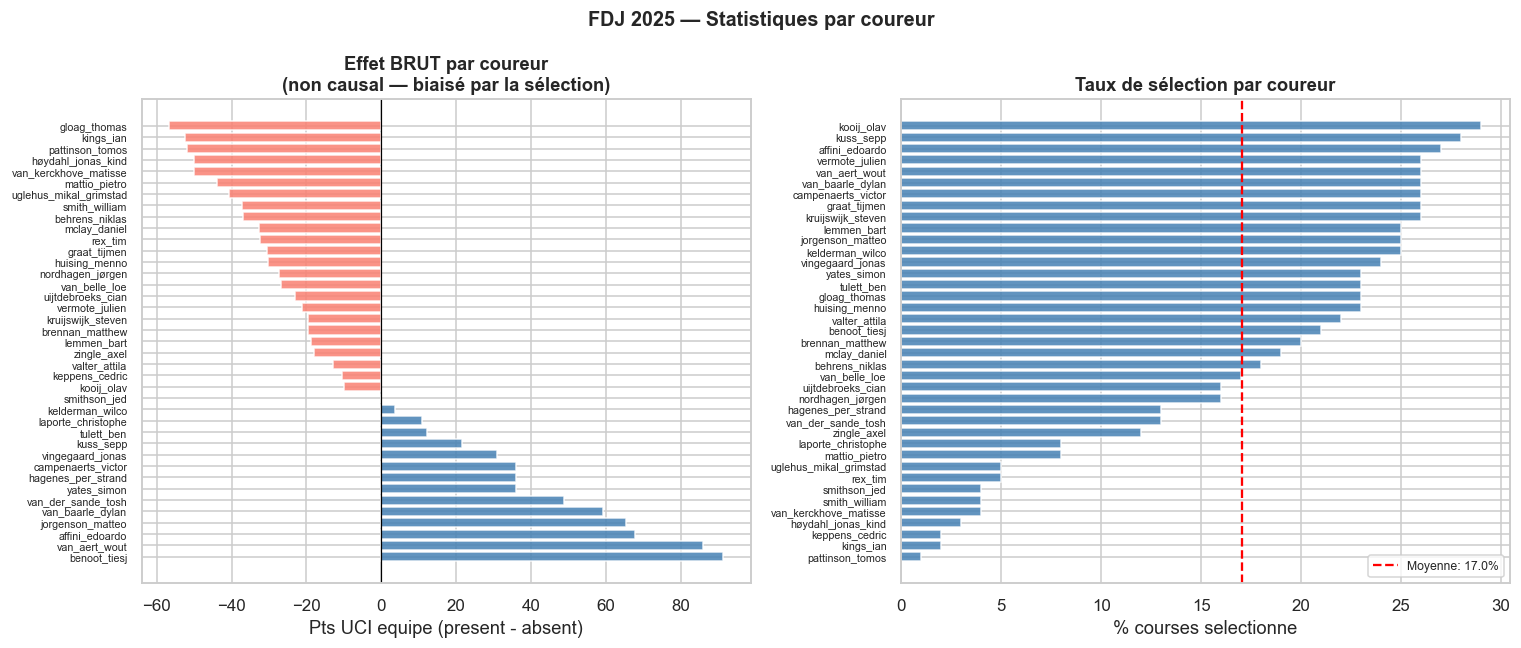

   Les effets bruts sont BIAISÉS : un coureur sélectionné sur de grandes courses
   semblera avoir un fort effet, même si ce sont les courses qui font les points.


IndexError: list index out of range

In [33]:
# ── 2.2 Taux de sélection et effet brut par coureur ────────────────────────
stats = df_fdj.groupby('rider').agg(
    n_courses=('selected', 'count'),
    n_selectionne=('selected', 'sum'),
    taux_selection=('selected', 'mean'),
    pts_present=('pts_uci_equipe', lambda x: x[df_fdj.loc[x.index, 'selected']==1].mean()),
    pts_absent=('pts_uci_equipe',  lambda x: x[df_fdj.loc[x.index, 'selected']==0].mean()),
).round(2)
stats['effet_brut'] = (stats['pts_present'] - stats['pts_absent']).round(2)
stats = stats.sort_values('effet_brut', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Effet brut par coureur
ax = axes[0]
colors_b = ['steelblue' if x > 0 else 'salmon' for x in stats['effet_brut']]
ax.barh(stats.index, stats['effet_brut'], color=colors_b, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pts UCI equipe (present - absent)')
ax.set_title('Effet BRUT par coureur\n(non causal — biaisé par la sélection)', fontweight='bold')
ax.tick_params(axis='y', labelsize=7)

# Taux de sélection
ax = axes[1]
stats_sorted = stats.sort_values('taux_selection', ascending=True)
ax.barh(stats_sorted.index, stats_sorted['taux_selection']*100,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('% courses selectionne')
ax.set_title('Taux de sélection par coureur', fontweight='bold')
ax.tick_params(axis='y', labelsize=7)
ax.axvline(stats['taux_selection'].mean()*100, color='red', linestyle='--',
           label=f'Moyenne: {stats["taux_selection"].mean()*100:.1f}%')
ax.legend(fontsize=8)

plt.suptitle('FDJ 2025 — Statistiques par coureur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('   Les effets bruts sont BIAISÉS : un coureur sélectionné sur de grandes courses')
print('   semblera avoir un fort effet, même si ce sont les courses qui font les points.')
nom_exemple = [r for r in stats.index if 'baptiste' in r.lower()][0]
print(f'  {nom_exemple} : {stats.loc[nom_exemple, "n_selectionne"]} sélections, effet brut = +{stats.loc[nom_exemple, "effet_brut"]:.0f} pts')
print(f'  → Sélectionné uniquement sur 5 grandes occasions → effet brut artificiellement élevé')

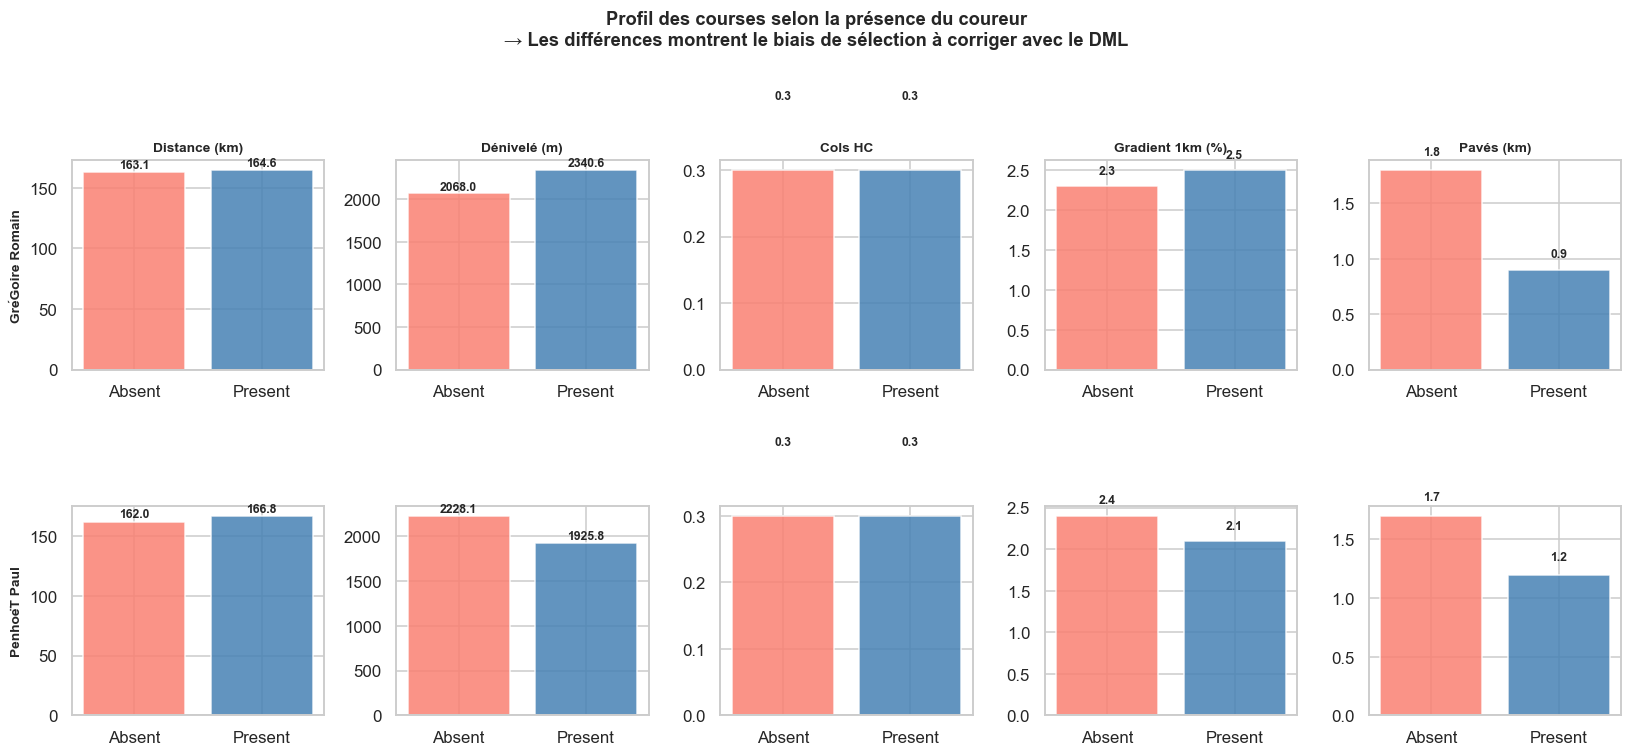

grégoire_romain :
          distance_gpx_km  denivele_pos  n_cols_hc  gradient_last_1km  \
selected                                                                
Absent             163.10       2068.00       0.30               2.30   
Present            164.60       2340.60       0.30               2.50   

          cobblestones_km  
selected                   
Absent               1.80  
Present              0.90  

penhoët_paul :
          distance_gpx_km  denivele_pos  n_cols_hc  gradient_last_1km  \
selected                                                                
Absent             162.00       2228.10       0.30               2.40   
Present            166.80       1925.80       0.30               2.10   

          cobblestones_km  
selected                   
Absent               1.70  
Present              1.20  

→ Deux profils très différents : Grégoire est sélectionné sur des courses accidentées,
  Penhoët sur des courses plus plates. Le DML corrige ces deux bia

In [ ]:
# ── 2.3 Biais de sélection — Grégoire vs Penhoët ──────────────────────────
# On montre sur quels types de courses chaque coureur est sélectionné
# C'est exactement le biais qu'on doit corriger avec le DML

cols_profil = ['distance_gpx_km', 'denivele_pos', 'n_cols_hc',
               'gradient_last_1km', 'cobblestones_km']
cols_profil = [c for c in cols_profil if c in df_fdj.columns]
labels_fr   = ['Distance (km)', 'Dénivelé (m)', 'Cols HC', 'Gradient 1km (%)', 'Pavés (km)']

# Recherche robuste des noms (évite les problèmes d'encodage d'accents)
nom_greg = [r for r in df_fdj['rider'].unique() if 'romain' in r][0]
nom_pen  = [r for r in df_fdj['rider'].unique() if 'penho' in r][0]
coureurs_focus = [nom_greg, nom_pen]

fig, axes = plt.subplots(2, len(cols_profil), figsize=(15, 7))

for row, coureur in enumerate(coureurs_focus):
    df_c = df_fdj[df_fdj['rider'] == coureur]
    profil = df_c.groupby('selected')[cols_profil].mean().round(1)

    for col_idx, (col, label) in enumerate(zip(cols_profil, labels_fr)):
        ax = axes[row, col_idx]
        vals = [profil.loc[0, col] if 0 in profil.index else 0,
                profil.loc[1, col] if 1 in profil.index else 0]
        bars = ax.bar(['Absent', 'Present'], vals,
                      color=['salmon', 'steelblue'], edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v*1.02 + 0.1,
                    f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
        if row == 0:
            ax.set_title(label, fontsize=9, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(coureur.replace('_', ' ').title(), fontsize=9, fontweight='bold')

plt.suptitle('Profil des courses selon la présence du coureur\n'
             '→ Les différences montrent le biais de sélection à corriger avec le DML',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print(f'{nom_greg} :')
df_g = df_fdj[df_fdj['rider'] == nom_greg]
print(df_g.groupby('selected')[cols_profil].mean().round(1).rename(index={0: 'Absent', 1: 'Present'}))

print(f'\n{nom_pen} :')
df_p = df_fdj[df_fdj['rider'] == nom_pen]
print(df_p.groupby('selected')[cols_profil].mean().round(1).rename(index={0: 'Absent', 1: 'Present'}))

print('\n→ Deux profils très différents : Grégoire est sélectionné sur des courses accidentées,')
print('  Penhoët sur des courses plus plates. Le DML corrige ces deux biais séparément.')

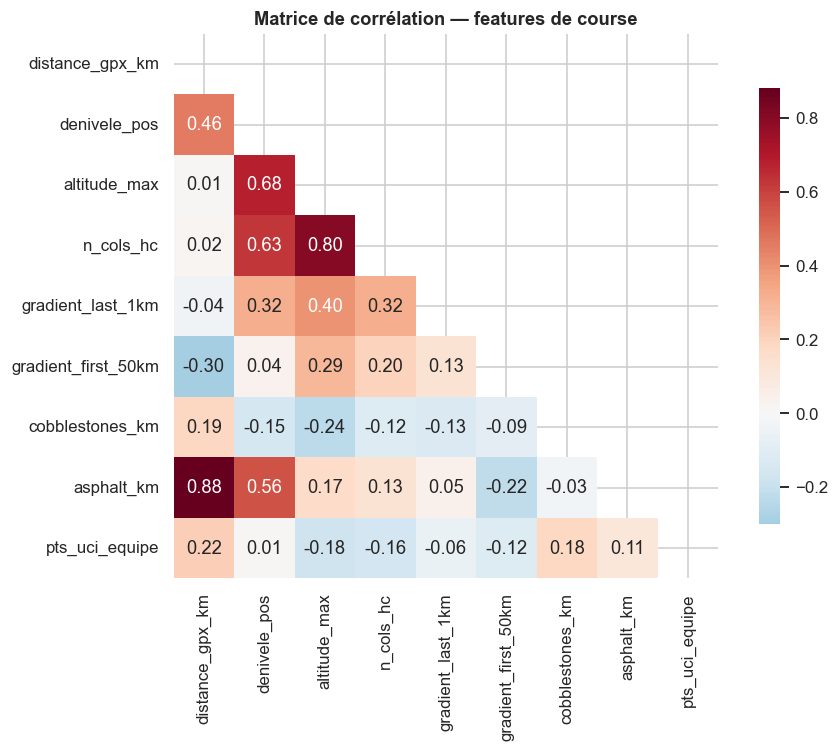

Correlation avec pts_uci_equipe :
distance_gpx_km        0.22
cobblestones_km        0.18
asphalt_km             0.11
denivele_pos           0.01
gradient_last_1km     -0.06
gradient_first_50km   -0.12
n_cols_hc             -0.16
altitude_max          -0.18
Name: pts_uci_equipe, dtype: float64


In [ ]:
# ── 2.4 Correlation features de course ─────────────────────────────────────
cols_corr = ['distance_gpx_km', 'denivele_pos', 'altitude_max',
             'n_cols_hc', 'gradient_last_1km', 'gradient_first_50km',
             'cobblestones_km', 'pts_uci_equipe']
cols_corr = [c for c in cols_corr if c in df_fdj.columns]

corr = df_fdj[cols_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, mask=mask, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation — features de course', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation avec l'outcome
print('Correlation avec pts_uci_equipe :')
print(corr['pts_uci_equipe'].drop('pts_uci_equipe').sort_values(ascending=False))

## 3. Pourquoi le ML classique ne suffit pas ?

### Le problème du biais de sélection

Si on compare naïvement `pts_uci_equipe` quand un coureur est présent vs absent, on mesure deux choses mélangées :
1. L'**effet causal** du coureur (ce qu'on veut)
2. L'**effet du type de course** (les grandes courses = plus de points, et les grands coureurs y vont)

### Pourquoi pas une régression simple ?
Une régression `pts_uci_equipe ~ selected + features_course` donnerait un coefficient sur `selected`, mais ce coefficient serait biaisé si les features de course ne capturent pas tous les confondants (ex. forme du coureur, objectifs tactiques).

### Pourquoi pas du propensity score matching ?
Le PSM trouve des "jumeaux" — des observations avec/sans le coureur sur des courses similaires. Ça marche bien en basse dimension, mais avec ~27 features de course, trouver de bons jumeaux est difficile (malédiction de la dimensionnalité).

### Pourquoi le DML ?
Le **Double Machine Learning** (Chernozhukov et al., 2018) combine la flexibilité du ML et la rigueur de l'inférence causale :
- Il utilise le ML pour **prédire** W (sélection) et Y (points) à partir de X (features de course)
- Il estime l'effet causal sur les **résidus** — la partie de W et Y non expliquée par X
- Le **cross-fitting** (estimation sur des folds séparés) garantit des propriétés statistiques valides

### Pourquoi le Causal Forest en plus ?
Le DML donne un effet **moyen** (ATE). Mais on veut savoir : l'effet de Grégoire est-il le même sur Paris-Roubaix et sur l'Alpe d'Huez ? Le **Causal Forest** estime un effet **individuel** τ(X) pour chaque course.

## 4. Double Machine Learning (DML)

### Les 3 étapes en détail

**Étape 1 — Résidu du traitement**
```
T_resid = selected - GBM.predict(features_course)
```
On prédit la probabilité que le coureur soit sélectionné à partir des features de la course.
Le résidu T̃ = ce qui n'est PAS expliqué par le type de course.

**Étape 2 — Résidu de l'outcome**
```
Y_resid = log(1+pts_equipe) - GBM.predict(features_course)
```
Le résidu Ỹ = performance anormale de l'équipe non expliquée par le type de course.

**Étape 3 — ATE**
```
ATE = Cov(Y_resid, T_resid) / Var(T_resid)
```
Si les performances anormales coïncident avec les présences anormales → effet positif.

**Cross-fitting (5 folds)** : on calcule les résidus sur des données que le modèle n'a pas vues pendant l'entraînement → évite l'overfitting dans l'estimation causale.

**Bootstrap (500 itérations)** : on ré-échantillonne les résidus pour construire l'IC à 95%.

In [ ]:
def prepare_features(df):
    features_gpx = [
        'distance_gpx_km', 'denivele_pos', 'denivele_neg',
        'altitude_max', 'altitude_min',
        'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
        'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc',
        'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
        'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km',
        'cobblestones_km','compacted_gravel_km'
    ]
    features_gpx = [f for f in features_gpx if f in df.columns]
    df = df.copy()
    le = LabelEncoder()
    df['classification_enc'] = le.fit_transform(df['classification'].fillna('unknown'))
    features_all = features_gpx + ['classification_enc']
    df_clean = df[features_all + ['selected', 'pts_uci_equipe', 'rider', 'course']].dropna(subset=features_gpx)
    X = df_clean[features_all].values
    T = df_clean['selected'].values
    Y = np.log1p(np.clip(df_clean['pts_uci_equipe'].values, 0, None))
    return X, T, Y, df_clean, features_all

def run_dml(X, T, Y, n_folds=5, n_boot=500):
    """
    Double Machine Learning avec cross-fitting.
    - On utilise GradientBoosting (pas un classifieur) car on estime une probabilite continue
    - n_folds : nombre de folds pour le cross-fitting
    - n_boot  : nombre de reechantillonnages pour l'IC bootstrap
    """
    if T.sum() < 5 or (T==0).sum() < 5:
        return None  # Pas assez de variation dans le traitement

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    T_resid = np.zeros(len(T))
    Y_resid = np.zeros(len(Y))

    # Cross-fitting : estimer les residus hors echantillon
    for train_idx, val_idx in kf.split(X):
        # Modele pour predire la selection W
        m_t = GradientBoostingRegressor(n_estimators=100, random_state=42)
        m_t.fit(X[train_idx], T[train_idx])
        T_resid[val_idx] = T[val_idx] - m_t.predict(X[val_idx])

        # Modele pour predire l'outcome Y
        m_y = GradientBoostingRegressor(n_estimators=100, random_state=42)
        m_y.fit(X[train_idx], Y[train_idx])
        Y_resid[val_idx] = Y[val_idx] - m_y.predict(X[val_idx])

    # ATE = regression des residus Y sur residus T
    ate = np.cov(Y_resid, T_resid)[0, 1] / np.var(T_resid)

    # Bootstrap pour l'IC 95%
    boots = []
    for _ in range(n_boot):
        idx = np.random.choice(len(T_resid), len(T_resid), replace=True)
        boots.append(np.cov(Y_resid[idx], T_resid[idx])[0, 1] / np.var(T_resid[idx]))
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])

    return {
        'ate_log':  ate,
        'ate_orig': np.expm1(ate),
        'ci_low':   np.expm1(ci_low),
        'ci_high':  np.expm1(ci_high),
        'significant': ci_low > 0 or ci_high < 0,
        'T_resid':  T_resid,
        'Y_resid':  Y_resid
    }

print('Fonctions DML chargees.')

Fonctions DML chargees.


In [ ]:
# ── DML sur tous les coureurs FDJ ──────────────────────────────────────────
print(f'Calcul DML pour {len(RIDERS)} coureurs...\n')
results_dml = []

for f in RIDERS:
    df_r = load_rider(f, ANNEE, EQUIPE)
    if df_r is None:
        continue
    X_r, T_r, Y_r, df_clean_r, features_all = prepare_features(df_r)
    nom = f.replace('.csv', '')
    brut = (df_clean_r[df_clean_r['selected']==1]['pts_uci_equipe'].mean() -
            df_clean_r[df_clean_r['selected']==0]['pts_uci_equipe'].mean())
    res = run_dml(X_r, T_r, Y_r)
    if res:
        results_dml.append({
            'rider': nom, 'n_obs': len(T_r), 'n_selected': int(T_r.sum()),
            'ate_orig': res['ate_orig'], 'ci_low': res['ci_low'],
            'ci_high': res['ci_high'], 'significant': res['significant'],
            'effet_brut': brut
        })
        sig = '✓' if res['significant'] else ' '
        print(f'  [{sig}] {nom:<35} ATE={res["ate_orig"]:+.2f}  IC=[{res["ci_low"]:+.2f}, {res["ci_high"]:+.2f}]')

df_results = pd.DataFrame(results_dml).sort_values('ate_orig', ascending=False)
print(f'\n→ {len(df_results)} coureurs analyses | {df_results["significant"].sum()} effets significatifs')

Calcul DML pour 38 coureurs...

  [✓] askey_lewis                         ATE=+1.05  IC=[+0.37, +2.13]
  [ ] barthe_cyril                        ATE=+0.14  IC=[-0.24, +0.71]
  [ ] bock_max                            ATE=-0.30  IC=[-0.66, +0.42]
  [ ] boulet_eliott                       ATE=-0.23  IC=[-0.58, +0.34]
  [✓] bower_lewis                         ATE=-0.48  IC=[-0.64, -0.26]
  [ ] braz_afonso_clément                ATE=+0.24  IC=[-0.18, +0.81]
  [ ] bystrøm_sven_erik                   ATE=-0.35  IC=[-0.60, +0.07]
  [ ] cavagna_rémi                       ATE=+0.03  IC=[-0.31, +0.53]
  [ ] daumas_rémi                        ATE=-0.14  IC=[-0.59, +0.91]
  [✓] davy_clément                       ATE=-0.37  IC=[-0.61, -0.03]
  [ ] decomble_maxime                     ATE=-0.16  IC=[-0.61, +0.63]
  [ ] donnenwirth_tom                     ATE=-0.21  IC=[-0.45, +0.16]
  [ ] fontaine_titouan                    ATE=-0.27  IC=[-0.58, +0.33]
  [ ] gaudu_david                         ATE

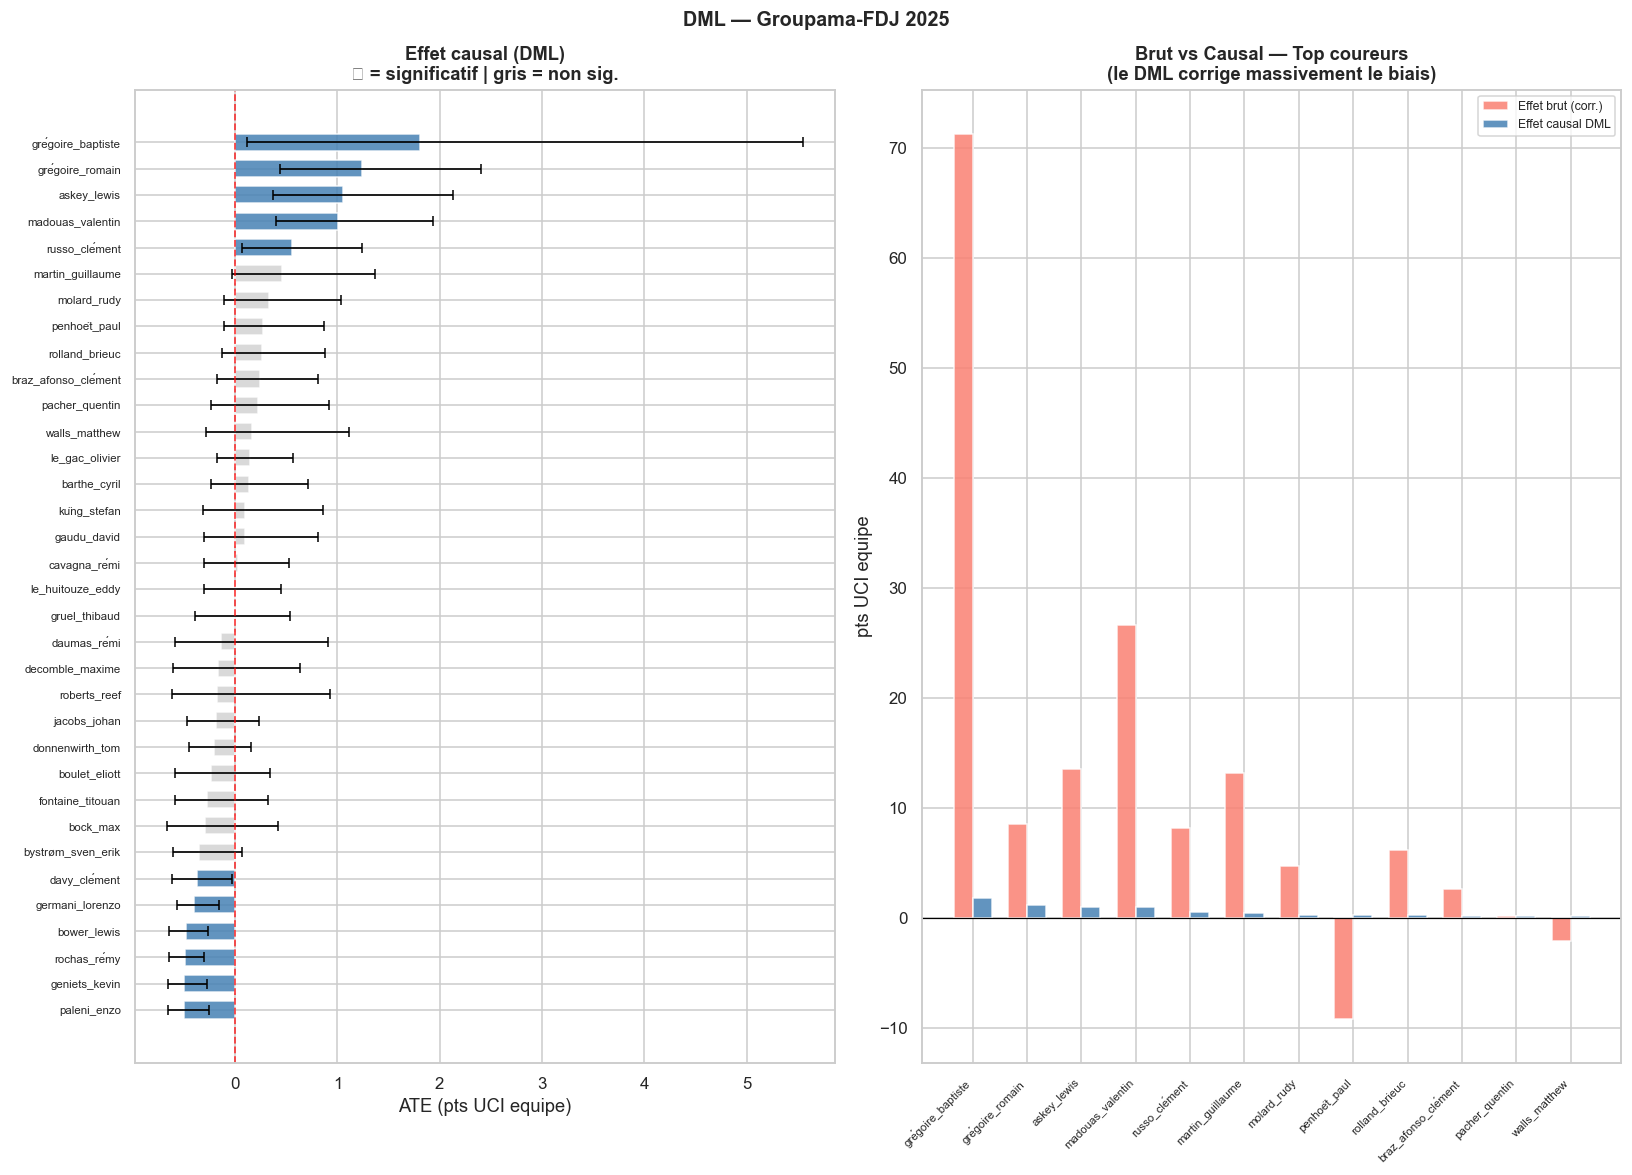

Lecture du graphe de gauche (forest plot) :
  - Chaque barre = ATE d un coureur
  - Les traits noirs = intervalle de confiance a 95% (bootstrap)
  - Barre bleue = effet significatif (IC ne contient pas 0)
  - Barre grise = effet non significatif (IC contient 0)
  - Ligne rouge = 0 (pas d effet)


In [ ]:
# ── Visualisation DML ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(df_results)*0.32)))

# Forest plot
df_plot = df_results.sort_values('ate_orig', ascending=True)
colors_f = ['steelblue' if s else 'lightgray' for s in df_plot['significant']]
y_pos = range(len(df_plot))
axes[0].barh(y_pos, df_plot['ate_orig'], color=colors_f, edgecolor='white', alpha=0.85, height=0.65)
axes[0].errorbar(df_plot['ate_orig'], y_pos,
    xerr=[df_plot['ate_orig']-df_plot['ci_low'], df_plot['ci_high']-df_plot['ate_orig']],
    fmt='none', color='black', capsize=3, linewidth=1.1)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=1.2)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_plot['rider'], fontsize=7.5)
axes[0].set_xlabel('ATE (pts UCI equipe)')
axes[0].set_title('Effet causal (DML)\n✓ = significatif | gris = non sig.', fontweight='bold')

# Effet brut vs causal
df_top = df_results.head(12)
x = np.arange(len(df_top))
w = 0.35
axes[1].bar(x - w/2, df_top['effet_brut'], w, label='Effet brut (corr.)', color='salmon', alpha=0.85)
axes[1].bar(x + w/2, df_top['ate_orig'],   w, label='Effet causal DML',   color='steelblue', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_top['rider'], rotation=45, ha='right', fontsize=7.5)
axes[1].set_ylabel('pts UCI equipe')
axes[1].set_title('Brut vs Causal — Top coureurs\n(le DML corrige massivement le biais)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle(f'DML — Groupama-FDJ {ANNEE}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Lecture du graphe de gauche (forest plot) :')
print('  - Chaque barre = ATE d un coureur')
print('  - Les traits noirs = intervalle de confiance a 95% (bootstrap)')
print('  - Barre bleue = effet significatif (IC ne contient pas 0)')
print('  - Barre grise = effet non significatif (IC contient 0)')
print('  - Ligne rouge = 0 (pas d effet)')

## 5. Causal Forest — Hétérogénéité de l'effet

### Pourquoi aller au-delà de l'ATE ?

L'ATE donne **une seule valeur** pour tous les coureurs et toutes les courses. Mais la vraie question sportive est plus fine :
- Grégoire est-il plus utile sur Paris-Roubaix ou sur l'Alpe d'Huez ?
- Est-ce que Küng apporte plus quand il y a un CLM dans la course ?

Le **Causal Forest DML** (Wager & Athey, 2018, implémenté dans EconML de Microsoft) estime un **CATE** — Conditional Average Treatment Effect — pour chaque observation.

### Comment ça marche ?
C'est exactement le DML, mais appliqué **localement** dans chaque feuille d'une forêt d'arbres. Les arbres sont construits pour maximiser l'**hétérogénéité** de l'effet entre les feuilles — pas pour prédire Y.

### Pourquoi GradientBoosting Regressor (et non Classifier) pour model_t ?
Même si `selected` est binaire (0/1), le Causal Forest a besoin d'une **probabilité continue** de participation. Le GBM Regressor prédit cette probabilité directement, ce qui est techniquement plus correct que d'utiliser un classifieur (qui optimise autre chose).

### Limites à garder en tête
- On **ne peut pas** évaluer les CATE comme on évalue un modèle ML classique (pas de vérité terrain)
- L'hypothèse d'**unconfoundedness** doit tenir : si des confondants importants manquent (forme du coureur, objectifs tactiques), les estimations sont biaisées
- Avec peu d'observations traitées (ex. 5 sélections), l'ATE individuel est très incertain

In [ ]:
# ── Causal Forest sur Romain Gregoire ──────────────────────────────────────
COUREUR_FOCUS = 'grégoire_romain.csv'

df_focus = load_rider(COUREUR_FOCUS, ANNEE, EQUIPE)
X_f, T_f, Y_f, df_f_clean, features_all = prepare_features(df_focus)
nom_focus = COUREUR_FOCUS.replace('.csv', '')

print(f'Causal Forest — {nom_focus}')
print(f'N observations : {len(T_f)} | selected=1 : {T_f.sum()} | selected=0 : {(T_f==0).sum()}')
print('Entrainement du Causal Forest...')

cf = CausalForestDML(
    # model_y : predit les pts_uci_equipe a partir des features de course
    model_y=GradientBoostingRegressor(n_estimators=100, random_state=42),
    # model_t : predit la probabilite de selection (GBM Regressor, pas Classifier)
    model_t=GradientBoostingRegressor(n_estimators=100, random_state=42),
    n_estimators=500,   # 500 arbres pour la stabilite
    random_state=42,
    cv=5                # cross-fitting a 5 folds (meme principe que le DML)
)
cf.fit(Y_f, T_f, X=X_f)

cate = cf.effect(X_f)  # effet individuel pour chaque observation
df_f_clean = df_f_clean.copy()
df_f_clean['cate'] = cate

print(f'\nResultats CATE :')
print(f'  Moyenne (= ATE approx.) : {cate.mean():.3f}')
print(f'  Ecart-type              : {cate.std():.3f}  (mesure l heterogeneite)')
print(f'  Min                     : {cate.min():.3f}')
print(f'  Max                     : {cate.max():.3f}')
print(f'  % effets positifs       : {(cate > 0).mean()*100:.1f}%')

Causal Forest — grégoire_romain
N observations : 265 | selected=1 : 69 | selected=0 : 196
Entrainement du Causal Forest...

Resultats CATE :
  Moyenne (= ATE approx.) : 0.803
  Ecart-type              : 0.452  (mesure l heterogeneite)
  Min                     : -0.491
  Max                     : 1.381
  % effets positifs       : 92.5%


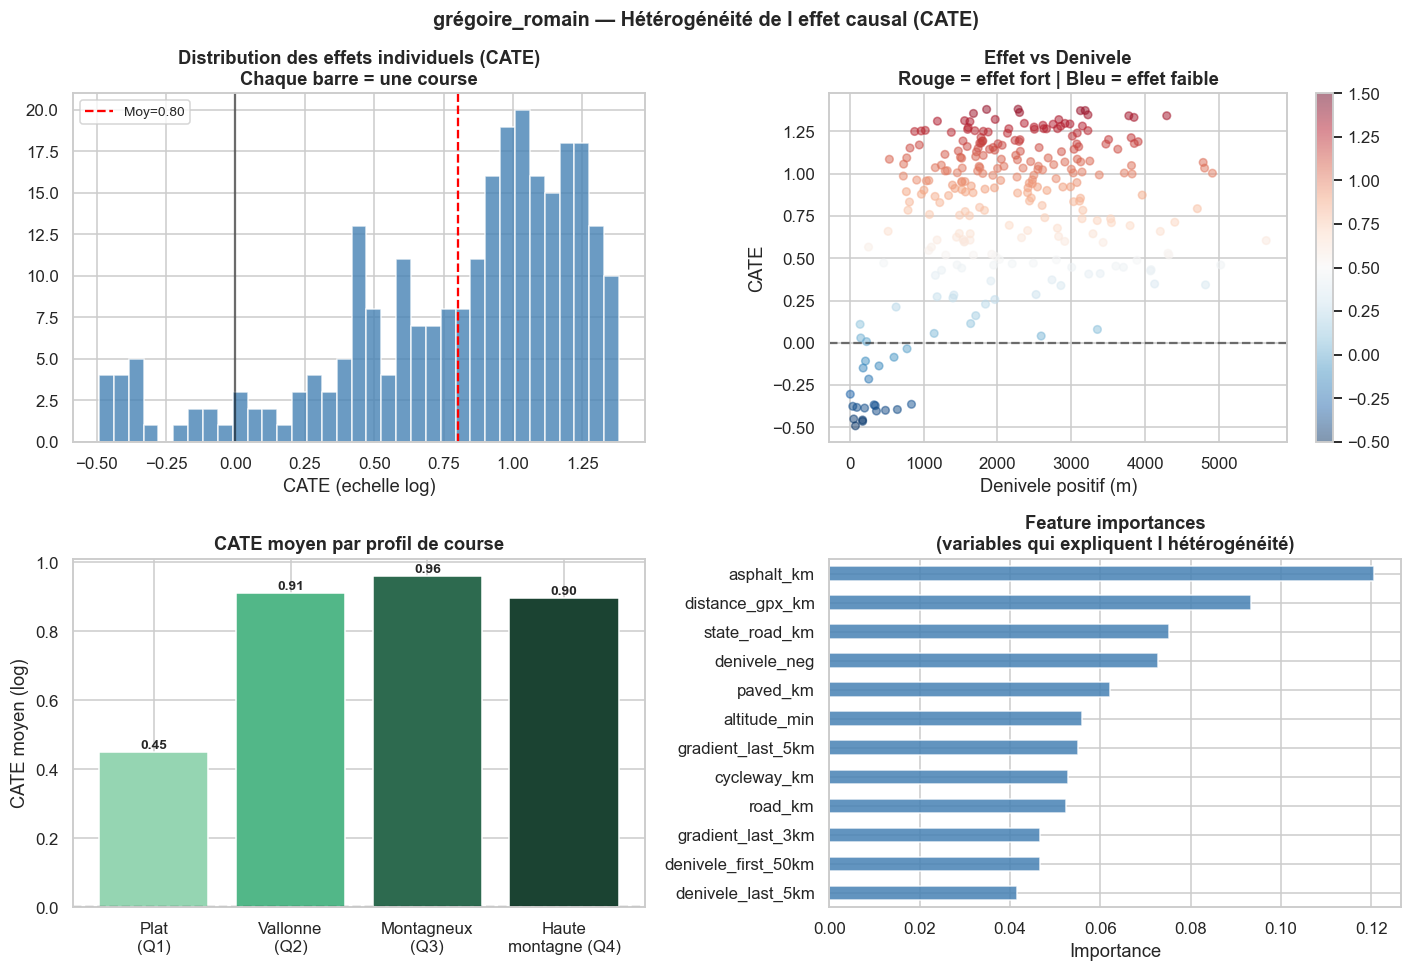

Interprétation :
  CATE Q1 (plat)         : 0.449 → effet modeste sur courses plates
  CATE Q4 (montagne)     : 0.896 → effet plus fort en montagne
  Top feature            : asphalt_km → variable qui explique le plus l heterogeneite


In [ ]:
# ── Visualisation Causal Forest ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Distribution CATE
ax = axes[0,0]
ax.hist(cate, bins=35, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(cate.mean(), color='red', linestyle='--', label=f'Moy={cate.mean():.2f}')
ax.axvline(0, color='black', alpha=0.5)
ax.set_title('Distribution des effets individuels (CATE)\nChaque barre = une course', fontweight='bold')
ax.set_xlabel('CATE (echelle log)')
ax.legend(fontsize=9)

# CATE vs denivele
ax = axes[0,1]
sc = ax.scatter(df_f_clean['denivele_pos'], cate, c=cate, cmap='RdBu_r',
                alpha=0.5, s=25, vmin=-0.5, vmax=1.5)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Denivele positif (m)')
ax.set_ylabel('CATE')
ax.set_title('Effet vs Denivele\nRouge = effet fort | Bleu = effet faible', fontweight='bold')
plt.colorbar(sc, ax=ax)

# CATE par quartile de denivele
ax = axes[1,0]
df_f_clean['denivele_q'] = pd.qcut(df_f_clean['denivele_pos'], q=4,
    labels=['Plat\n(Q1)', 'Vallonne\n(Q2)', 'Montagneux\n(Q3)', 'Haute\nmontagne (Q4)'])
cate_q = df_f_clean.groupby('denivele_q')['cate'].mean()
bars = ax.bar(cate_q.index, cate_q.values,
              color=['#95d5b2','#52b788','#2d6a4f','#1b4332'], edgecolor='white')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title('CATE moyen par profil de course', fontweight='bold')
ax.set_ylabel('CATE moyen (log)')
for bar, val in zip(bars, cate_q.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.2f}',
            ha='center', fontsize=9, fontweight='bold')

# Feature importances
ax = axes[1,1]
feat_imp = pd.Series(cf.feature_importances_, index=features_all).sort_values(ascending=True).tail(12)
feat_imp.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Feature importances\n(variables qui expliquent l hétérogénéité)', fontweight='bold')
ax.set_xlabel('Importance')

plt.suptitle(f'{nom_focus} — Hétérogénéité de l effet causal (CATE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interprétation :')
print(f'  CATE Q1 (plat)         : {cate_q.iloc[0]:.3f} → effet modeste sur courses plates')
print(f'  CATE Q4 (montagne)     : {cate_q.iloc[3]:.3f} → effet plus fort en montagne')
print(f'  Top feature            : {feat_imp.index[-1]} → variable qui explique le plus l heterogeneite')

## 6. Questions ouvertes pour Bram & Dries

### Sur les données
- **Confondants manquants** : on n'a pas la **forme récente** du coureur comme confondant. Un coureur est sélectionné en partie parce qu'il est en forme — et sa forme affecte aussi les points de l'équipe. Faut-il calculer une moyenne des pts_uci sur les 30 derniers jours ?
- **Unconfoundedness** : l'hypothèse centrale du DML est que, conditionnellement aux features de course, la sélection est indépendante des résultats potentiels. Est-ce raisonnable ici ? Quels confondants inobservés vous semblent les plus importants (blessures, objectifs tactiques) ?
- **Unité d'analyse** : on modélise au niveau étape. Faut-il agréger toutes les étapes d'un Grand Tour en une seule observation ?

### Sur la méthode
- **ATE faibles** : les ATE sont entre -0.5 et +1.8 pts sur l'échelle originale. Est-ce attendu ? Ou cela suggère-t-il un problème dans la modélisation ?
- **Évaluation des CATE** : comment évaluer la qualité de nos estimations CATE ? Vous mentionniez la R-Loss et la DR-Loss dans vos ressources — faut-il les implémenter ?
- **Placebo test** : pour valider le modèle, devrait-on tester si on détecte un effet nul sur un coureur qui n'a jamais participé (selected toujours 0) ?

### Sur les prochaines étapes
- Étendre l'analyse à d'autres équipes WT pour comparer les profils
- Analyser les effets **conditionnels** : impact d'un équipier selon la présence/absence de son leader
- Construire la **recommandation de calendrier** : quelles courses donner à quel coureur pour maximiser les points ?